Dynamic Pricing Engine

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
EVENTS_PATH = 'ModelData/events.csv'
PRODUCTS_PATH = 'ModelData/products.csv'
SESSIONS_PATH = 'ModelData/sessions.csv'
CUSTOMERS_PATH = 'ModelData/customers.csv'

df_events = pd.read_csv(EVENTS_PATH)
df_products = pd.read_csv(PRODUCTS_PATH)
df_sessions = pd.read_csv(SESSIONS_PATH)
df_customers = pd.read_csv(CUSTOMERS_PATH)

datasets = {
    "Events": df_events,
    "Products": df_products,
    "Sessions": df_sessions,
    "Customers": df_customers
}

print("**Details of DataFrame Content**")
for name, df in datasets.items():
    print(f"Name: {name}, Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Identity Fields in {name}:")
    for i in df.columns:
        if '_id' in i:
            print(i)

**Details of DataFrame Content**
Name: Events, Rows: 760958, Columns: 10
Identity Fields in Events:
event_id
session_id
product_id
Name: Products, Rows: 1197, Columns: 6
Identity Fields in Products:
product_id
Name: Sessions, Rows: 120000, Columns: 6
Identity Fields in Sessions:
session_id
customer_id
Name: Customers, Rows: 20000, Columns: 7
Identity Fields in Customers:
customer_id


In [3]:
#creating the master dataframe

df_merged = pd.merge(df_events, df_products, on='product_id', how='left')
df_merged = pd.merge(df_merged, df_sessions, on='session_id', how='left')
masterdf = pd.merge(df_merged, df_customers, on='customer_id', how='left')

print("**Structural Overview* of Master DataFrame*")
print(masterdf.info())

**Structural Overview* of Master DataFrame*
<class 'pandas.DataFrame'>
RangeIndex: 760958 entries, 0 to 760957
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   event_id          760958 non-null  int64  
 1   session_id        760958 non-null  int64  
 2   timestamp         760958 non-null  str    
 3   event_type        760958 non-null  str    
 4   product_id        682469 non-null  float64
 5   qty               143126 non-null  float64
 6   cart_size         44909 non-null   float64
 7   payment           33580 non-null   str    
 8   discount_pct      33580 non-null   float64
 9   amount_usd        33580 non-null   float64
 10  category          682469 non-null  str    
 11  name_x            682469 non-null  str    
 12  price_usd         682469 non-null  float64
 13  cost_usd          682469 non-null  float64
 14  margin_usd        682469 non-null  float64
 15  customer_id       760958 non-null  

**Total successful purchase orders captured: 33,580**


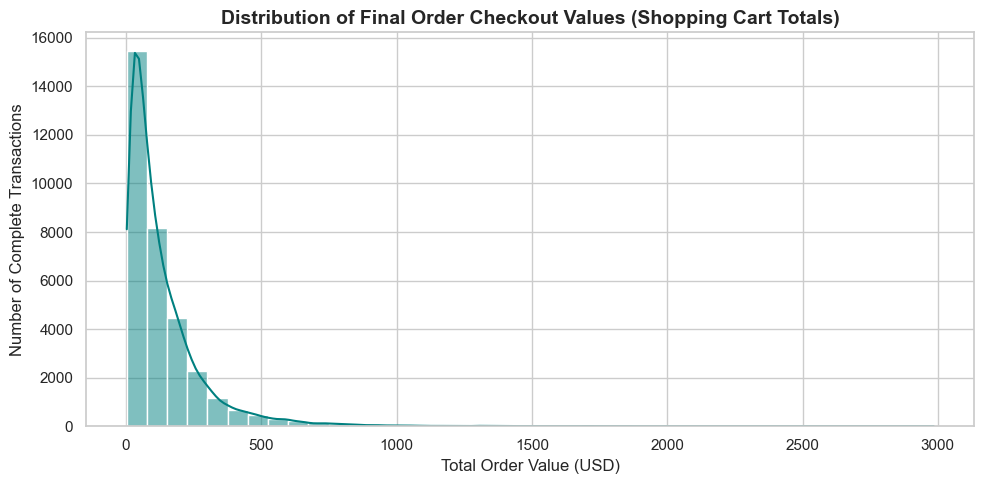

In [4]:
#extracting data from completed purchases
purchase_events = masterdf[masterdf['event_type'] == 'purchase']

print(f"**Total successful purchase orders captured: {len(purchase_events):,}**")

plt.figure(figsize=(10, 5))
sns.histplot(data=purchase_events, x='amount_usd', bins=40, color='teal', kde=True)

plt.title("Distribution of Final Order Checkout Values (Shopping Cart Totals)", fontsize=14, fontweight='bold')
plt.xlabel("Total Order Value (USD)", fontsize=12)
plt.ylabel("Number of Complete Transactions", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# grouping purchases with session_ids
print("**Model Input Features**")

purchased_sessions = set(masterdf[masterdf['event_type'] == 'purchase']['session_id'])

page_views = masterdf[masterdf['event_type'] == 'page_view'].groupby('product_id').size().rename('page_view')
add_to_carts = masterdf[masterdf['event_type'] == 'add_to_cart'].groupby('product_id').size().rename('add_to_cart')

cart_events = masterdf[masterdf['event_type'] == 'add_to_cart'].copy()
# adding all the add_to_cart event types where it leads to a puchase by giving it a binary value
# only add_to_cart event types have product_ids
cart_events['is_purchased'] = cart_events['session_id'].isin(purchased_sessions).astype(int)
# product_id and their number of purchases
product_purchases = cart_events.groupby('product_id')['is_purchased'].sum().rename('purchase_count')

product_base = df_products.set_index('product_id')[['price_usd', 'cost_usd', 'category']]

# joining financial data with features
features_df = product_base.join(page_views,how='left').fillna(0)
features_df = features_df.join(add_to_carts, how='left').fillna(0)
features_df = features_df.join(product_purchases, how='left').fillna(0)

# creating advanced features to train the model


**Model Input Features**
            price_usd  cost_usd     category
product_id                                  
1              570.28    352.69  Electronics
2              498.13    263.13  Electronics
3              548.53    309.60  Electronics
4              268.36    153.56  Electronics
5               63.69     42.65  Electronics
...               ...       ...          ...
1193            12.64      7.36         Toys
1194            16.94     11.55         Toys
1195             6.51      3.40         Toys
1196            21.83     13.44         Toys
1197            48.51     27.32         Toys

[1197 rows x 3 columns]
